In [375]:
%matplotlib inline


# Pattern Reversal VEP Visualization

This example demonstrates loading, organizing, and visualizing EP response data
from the Visual Pattern Reversal VEP (PR-VEP) experiment.

An animation of a checkerboard reversal is shown (the checkerboard squares'
colours are toggled once each half a second).

The data used is the first subject and first session of the eeg-expy PR-VEP
example dataset, recorded using an OpenBCI Cyton with a Tencom 20 channel cap, with cup 
electrodes placed at (Fp1, Fp2, T5, T6, O1, O2, Oz, M2) fitted around a Meta
Quest 2 headset. The session used the Meta Quest 2 linked with a PC to
display the checkerboard reversal animation in VR at 120 Hz, alternating
monocular stimulation between left and right eye across blocks.

We first use ``fetch_dataset`` to obtain the data files. If the files are not
already present in the local data directory they will be downloaded from the
cloud.

After loading the data from the occipital channels, we place it in an MNE
``Epochs`` object, and then an ``Evoked`` object to obtain the trial-averaged
response. The final figures show the P100 response ERP waveform, a comparison
between eyes, and the interocular difference wave.


## Setup



In [376]:
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd

from mne import Epochs, find_events, concatenate_raws

from eegnb import get_recording_dir
from eegnb.analysis.utils import load_csv_as_raw
from eegnb.analysis.vep_utils import plot_vep
from eegnb.devices.utils import EEG_INDICES, SAMPLE_FREQS
# sphinx_gallery_thumbnail_number = 3

## Hardware lag definitions

Known display-pipeline offsets for different setups, subtracted from epoch
times so t=0 corresponds to actual photon delivery on the user's retina.

The offset shifts the software marking time forward to account for the VR
compositor look-ahead plus USB and panel latency, aligning the measured P100
to the clinical ~100 ms peak.



In [377]:
quest_link_photon_lag = 0.1

## Load Data

Download the PR-VEP example dataset if it is not already present locally.




In [378]:

session_dir = get_recording_dir('cyton', 'visual-PRVEP', subject_id=0, session_nb=6, site='quest-2_120Hz_cap', data_dir=os.getenv("DATA_DIR"))
csv_paths = sorted(p for p in session_dir.glob('recording_*.csv')
                   if not p.name.endswith('_timing.csv'))
print(f"\nFound {len(csv_paths)} recording(s) in {session_dir}")
for p in csv_paths:
    print(f"  {p.name}")

# Load each recording separately so events can be aligned 1:1 with its
# timing sidecar . a trailing marker pushed after the EEG stream closes leaves
# one extra timing row, which we truncate per-file before concatenation.
per_recording = []
for p in csv_paths:
    rec_raw = load_csv_as_raw([str(p)], sfreq=SAMPLE_FREQS['cyton'], ch_ind=EEG_INDICES['cyton'])
    rec_timing = pd.read_csv(p.parent / f'{p.stem}_timing.csv')
    rec_events = find_events(rec_raw, shortest_event=1, verbose=False)
    n = min(len(rec_events), len(rec_timing))
    if len(rec_events) != len(rec_timing):
        print(f"[warn] {p.name}: events={len(rec_events)}, timing={len(rec_timing)} . truncating to {n}")
    per_recording.append({
        'raw': rec_raw,
        'events': rec_events[:n],
        'timing': rec_timing.iloc[:n].reset_index(drop=True),
    })

raw, events = concatenate_raws(
    [rec['raw'] for rec in per_recording],
    events_list=[rec['events'] for rec in per_recording],
)
timing_df = pd.concat([rec['timing'] for rec in per_recording], ignore_index=True)
assert len(events) == len(timing_df), "per-file truncation should keep events and timing aligned"

def log_channel_stats(label, data_uV, ch_names):
    """data_uV: (n_channels, n_samples) in uV. Prints std, median-abs, max-abs per channel."""
    print(f"\n[{label}] per-channel stats (uV)")
    print(f"  {'ch':<6}{'std':>10}{'med|x|':>10}{'max|x|':>12}")
    for i, ch in enumerate(ch_names):
        x = data_uV[i]
        print(f"  {ch:<6}{np.std(x):>10.2f}{np.median(np.abs(x)):>10.2f}{np.max(np.abs(x)):>12.2f}")


print(f"\n[raw] sfreq={raw.info['sfreq']} Hz, n_samples={raw.n_times}, duration={raw.times[-1]:.1f}s")
print(f"[raw] channels: {raw.ch_names}")
log_channel_stats('raw (pre-filter)', raw.get_data(picks='eeg') * 1e6, raw.copy().pick('eeg').ch_names)



Found 1 recording(s) in C:\Users\pelle\.eegnb\data\visual-PRVEP\quest-2_120Hz_cap\cyton\subject0000\session006
  recording_2026-04-20-10.16.43.csv


Loading these files: 

C:\Users\pelle\.eegnb\data\visual-PRVEP\quest-2_120Hz_cap\cyton\subject0000\session006\recording_2026-04-20-10.16.43.csv




['Fp1', 'Fp2', 'T5', 'T6', 'O1', 'O2', 'Oz', 'Pz', 'stim']
['Fp1', 'Fp2', 'T5', 'T6', 'O1', 'O2', 'Oz', 'Pz', 'stim']
Creating RawArray with float64 data, n_channels=9, n_times=107310
    Range : 0 ... 107309 =      0.000 ...   429.236 secs
Ready.

[raw] sfreq=250.0 Hz, n_samples=107310, duration=429.2s
[raw] channels: ['Fp1', 'Fp2', 'T5', 'T6', 'O1', 'O2', 'Oz', 'Pz', 'stim']

[raw (pre-filter)] per-channel stats (uV)
  ch           std    med|x|      max|x|
  Fp1       530.16  41126.14    42050.27
  Fp2       217.72  35935.93    36781.09
  T5        243.38   8042.83     8594.56
  T6       7610.38  26502.41    34369.45
  O1       2324.53 106495.75   108492.48
  O2        115.86   7272.61     

## Visualize the power spectrum



NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


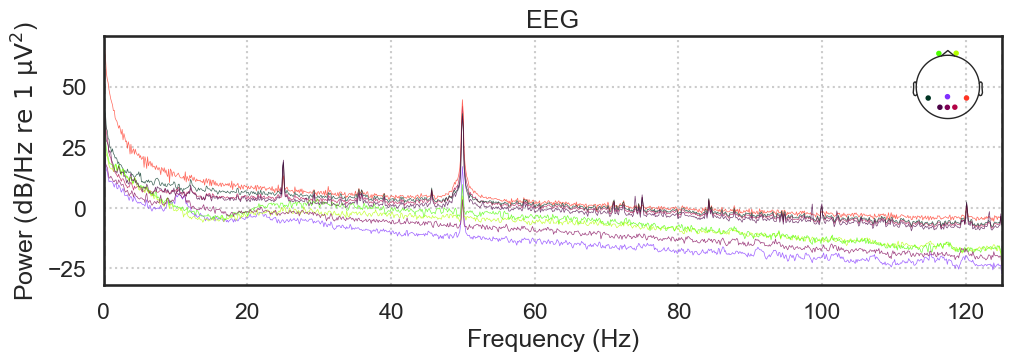

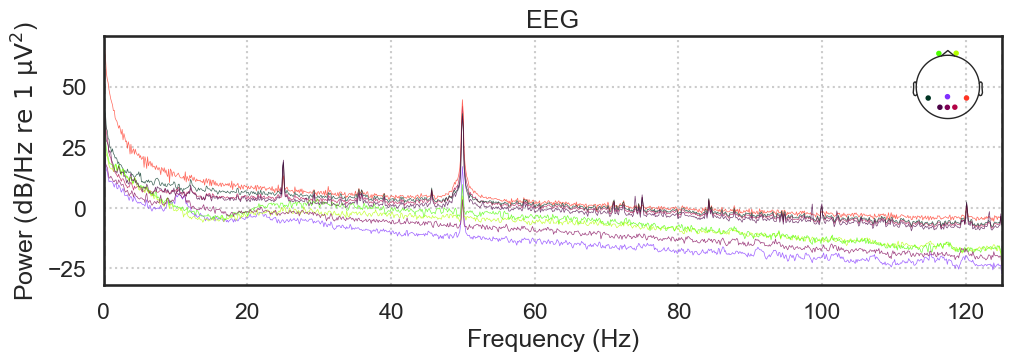

In [379]:
raw.plot_psd()

## Filtering

Use FIR rather than IIR to keep linear phase. IIR's frequency-dependent group
delay would shift the P100 peak by an amount that depends on its spectral
content, contaminating latency measurements. FIR applies the same delay to
every frequency, and MNE's zero-phase filtering cancels even that constant
shift so the filtered P100 sits at the same sample as the unfiltered one.


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 825 samples (3.300 s)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).

[post-filter 1-30 Hz] per-channel stats (uV)
  ch           std    med|x|      max|x|
  Fp1        14.37      4.77      180.98
  Fp2        12.33      3.85      176.96
  T5         28.26     12.58      339.92
  T6        270.31     36.96     4608.44
  O1         38.08      9.22  

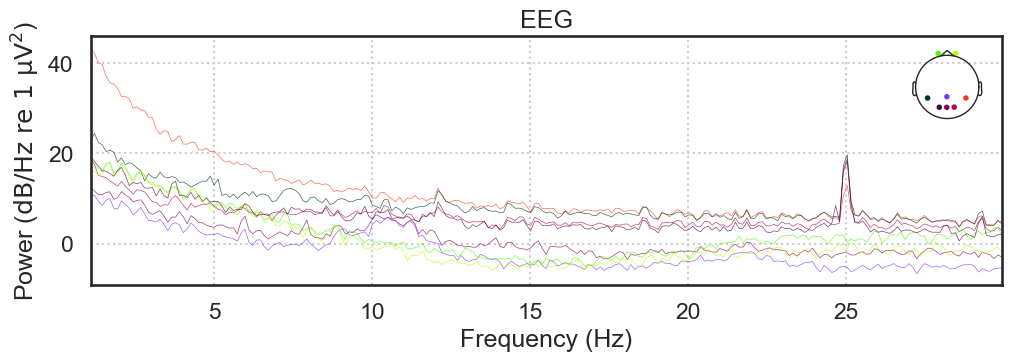

In [380]:
hp, lp = 1, 30
raw.filter(hp, lp, method='fir')
raw.plot_psd(fmin=hp, fmax=lp)
log_channel_stats(f'post-filter {hp}-{lp} Hz', raw.get_data(picks='eeg') * 1e6, raw.copy().pick('eeg').ch_names)

## Per-trial compositor-lookahead correction

Each event sample index is shifted by the per-trial variation in the Quest
compositor's predicted_display_time, correcting trial-by-trial timing jitter.
The residual absolute offset is captured in quest_link_photon_lag.

In [381]:
offsets_s = timing_df['predicted_display_time'].values - timing_df['software_time'].values
rel_offsets_s = offsets_s - offsets_s.mean()
sample_shifts = np.round(rel_offsets_s * raw.info['sfreq']).astype(int)
print(f"\n[lookahead] per-trial compositor jitter (ms):  "
      f"min={rel_offsets_s.min()*1000:+.2f}  "
      f"max={rel_offsets_s.max()*1000:+.2f}  "
      f"std={rel_offsets_s.std()*1000:.2f}  "
      f"|shift| samples: max={np.abs(sample_shifts).max()}")
# Per-trial jitter-corrected event array. Kept separate from the raw `events` so
# both can be overlaid on evoked plots (raw = solid, corrected = dashed) to
# show side-by-side whether the per-trial compositor-lookahead shift helps.
events_corrected = events.copy()
events_corrected[:, 0] += sample_shifts


[lookahead] per-trial compositor jitter (ms):  min=-32.15  max=+13.15  std=4.07  |shift| samples: max=8


## Epoching

Epoch around stimulus onsets, separating left- and right-eye trials.




In [382]:
event_id = {'left_eye': 1, 'right_eye': 2}
print(f"\n[events] total={len(events)}, "
      f"left_eye={int((events[:, 2] == 1).sum())}, "
      f"right_eye={int((events[:, 2] == 2).sum())}")
epoch_metadata = timing_df

# Oz is the ISCEV-standard electrode.
PICK_CH = 'Pz'
REJECT_UV = 35e-6
ch_epochs = Epochs(raw, events=events, event_id=event_id,
                   tmin=-0.1, tmax=0.4, baseline=None,
                   reject={'eeg': REJECT_UV},
                   preload=True,
                   verbose=False, picks=[PICK_CH],
                   metadata=epoch_metadata,
                   event_repeated='drop')
ch_epochs.shift_time(-quest_link_photon_lag)

n_left = len(ch_epochs['left_eye'])
n_right = len(ch_epochs['right_eye'])
n_total = n_left + n_right
drop_pct = (1 - n_total / len(events)) * 100
print(f"\n[{PICK_CH} epochs] reject ptp = {REJECT_UV * 1e6:.0f} uV")
print(f"  kept {n_total}/{len(events)}  "
      f"(left={n_left}, right={n_right})  drop={drop_pct:.1f}%")

# Peak-to-peak distribution on surviving epochs.
ch_ptp = np.ptp(ch_epochs.get_data(picks=[PICK_CH])[:, 0, :] * 1e6, axis=-1)
print(f"  {PICK_CH} ptp uV:  min={ch_ptp.min():.1f}  median={np.median(ch_ptp):.1f}  "
      f"p90={np.percentile(ch_ptp, 90):.1f}  max={ch_ptp.max():.1f}")

# Corrected-events epochs on the same trial set (ch_epochs.selection) for overlay.
ch_epochs_corr = Epochs(raw, events=events_corrected[ch_epochs.selection],
                        event_id=event_id, tmin=-0.1, tmax=0.4, baseline=None,
                        reject=None, preload=True, verbose=False, picks=[PICK_CH],
                        metadata=epoch_metadata.iloc[ch_epochs.selection].reset_index(drop=True),
                        event_repeated='drop')
ch_epochs_corr.shift_time(-quest_link_photon_lag)


[events] total=800, left_eye=400, right_eye=400

[Pz epochs] reject ptp = 35 uV
  kept 734/800  (left=362, right=372)  drop=8.3%
  Pz ptp uV:  min=10.1  median=19.9  p90=28.3  max=34.8


<Epochs | 734 events (all good), -0.2 – 0.3 s (baseline off), ~733 KiB, data loaded, with metadata,
 'left_eye': 362
 'right_eye': 372>

## Oz evoked per eye


N75 Peak of -4.09 µV at 21.59 ms in peak_channel Pz
P100 Peak of 0.13 µV at 106.16 ms in peak_channel Pz
N145 Peak of -1.08 µV at 132.79 ms in peak_channel Pz
Need more than one channel to make topography for eeg. Disabling interactivity.


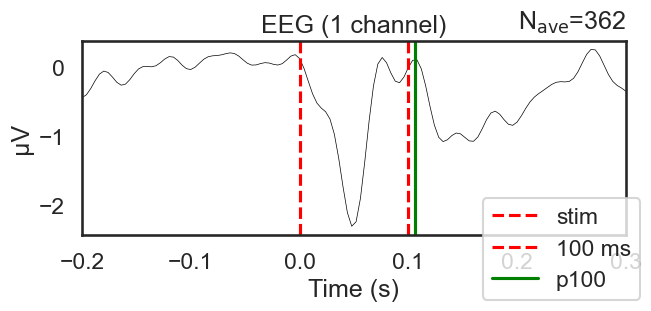

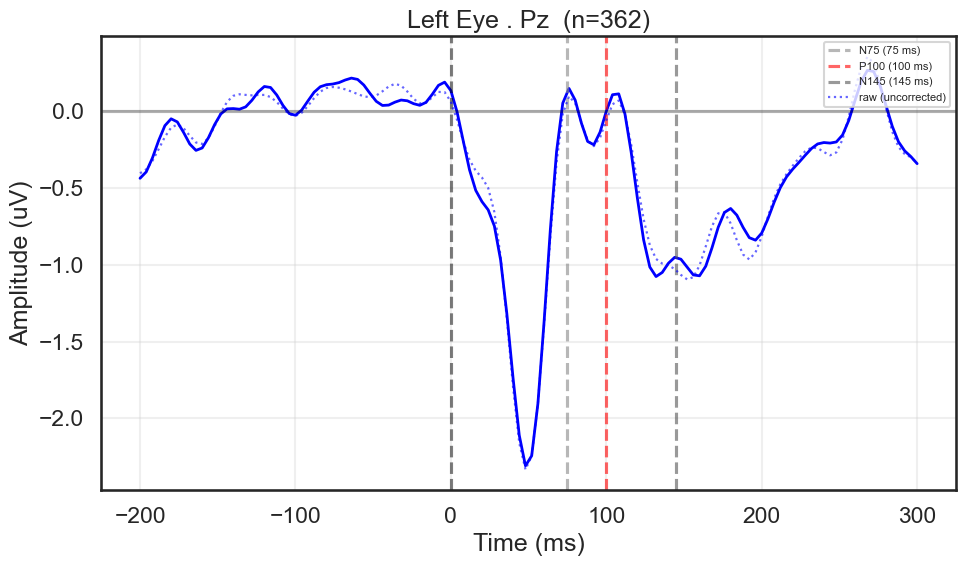

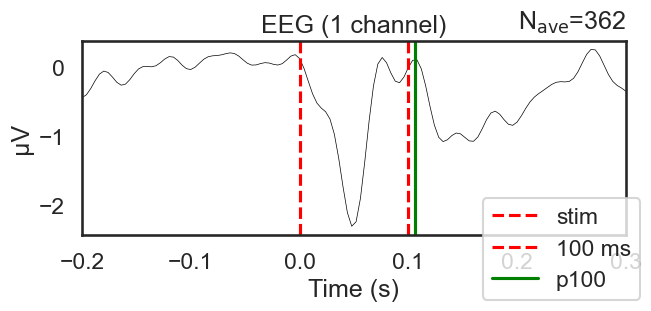

In [383]:
evoked_left = ch_epochs['left_eye'].average(picks=[PICK_CH])
evoked_right = ch_epochs['right_eye'].average(picks=[PICK_CH])

times = evoked_left.times * 1000
left_data = evoked_left.data[0] * 1e6
right_data = evoked_right.data[0] * 1e6

LANDMARK_MS = [75, 100, 145]  # N75, P100, N145
LANDMARK_COLORS = ['#888888', 'red', '#555555']
LANDMARK_LABELS = ['N75 (75 ms)', 'P100 (100 ms)', 'N145 (145 ms)']


def plot_ch(ax, data, title, color):
    ax.plot(times, data, color=color, linewidth=2)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (uV)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    for ms, col, lbl in zip(LANDMARK_MS, LANDMARK_COLORS, LANDMARK_LABELS):
        ax.axvline(x=ms, color=col, linestyle='--', alpha=0.6, label=lbl)
    ax.legend(fontsize=8, loc='upper right')


evoked_left_corr  = ch_epochs_corr['left_eye'].average(picks=[PICK_CH])
evoked_right_corr = ch_epochs_corr['right_eye'].average(picks=[PICK_CH])
left_corr  = evoked_left_corr.data[0] * 1e6
right_corr = evoked_right_corr.data[0] * 1e6

fig_l, ax_l = plt.subplots(figsize=(10, 6))
plot_ch(ax_l, left_corr, f'Left Eye . {PICK_CH}  (n={len(ch_epochs["left_eye"])})', 'blue')
ax_l.plot(times, left_data, color='blue', linestyle=':', alpha=0.6, linewidth=1.6, label='raw (uncorrected)')
ax_l.legend(fontsize=8, loc='upper right')
fig_l.tight_layout()

plot_vep(evoked_left_corr)


N75 Peak of -0.06 µV at 67.17 ms in peak_channel Pz
P100 Peak of 0.47 µV at 94.6 ms in peak_channel Pz
N145 Peak of -1.03 µV at 148.62 ms in peak_channel Pz
Need more than one channel to make topography for eeg. Disabling interactivity.


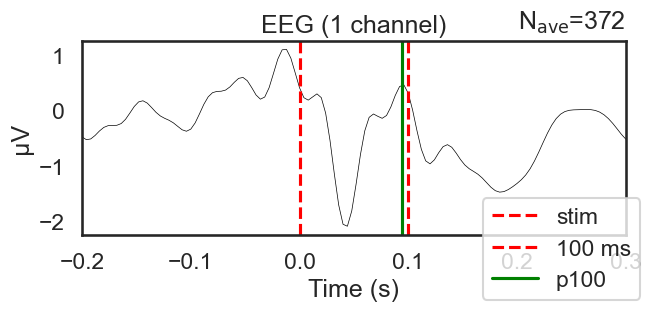

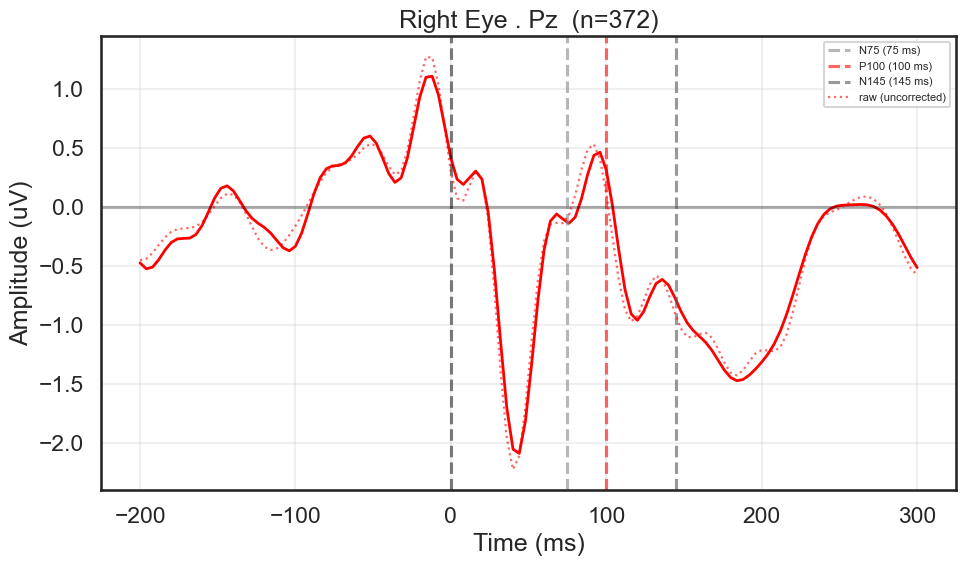

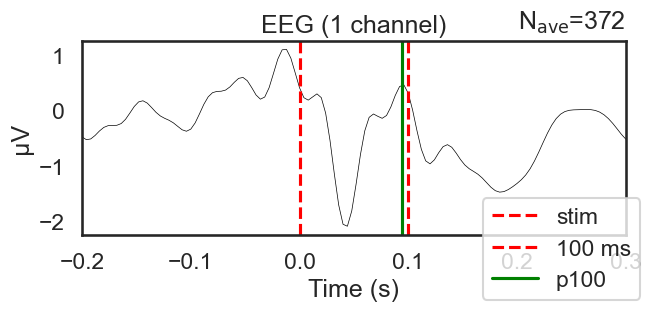

In [384]:

fig_r, ax_r = plt.subplots(figsize=(10, 6))
plot_ch(ax_r, right_corr, f'Right Eye . {PICK_CH}  (n={len(ch_epochs["right_eye"])})', 'red')
ax_r.plot(times, right_data, color='red', linestyle=':', alpha=0.6, linewidth=1.6, label='raw (uncorrected)')
ax_r.legend(fontsize=8, loc='upper right')
fig_r.tight_layout()
plot_vep(evoked_right_corr)